# Root Cause Analysis - Uber

## Problem Statement
Uber has received some complaints from their customers facing problems related to ride cancellations by the driver and non-availability of cars
for a specific route in the city.
The uneven supply-demand gap for cabs from City to Airport and vice-versa is causing a bad effect on customer relationships as well as Uber is
losing out on its revenue.
The aim of analysis is to identify the root cause of the problem (i.e. cancellation and non-availability of cars) and recommend ways to tackle the
situation.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [39]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('uber-data.csv', parse_dates=[4,5], dayfirst=True, na_values='NA')
df.head()

Saving uber-data.csv to uber-data (1).csv


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [40]:
df['Request timestamp_1'] = pd.to_datetime(df['Request timestamp'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
df['Request timestamp_2']= pd.to_datetime(df['Request timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
df['Request timestamp']=df['Request timestamp_2'].combine_first(df['Request timestamp_1'])

In [41]:
df['Drop timestamp_1'] = pd.to_datetime(df['Drop timestamp'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
df['Drop timestamp_2']=pd.to_datetime(df['Drop timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
df['Drop timestamp']=df['Drop timestamp_2'].combine_first(df['Drop timestamp_1'])

In [42]:
print("No. of rows: {}".format(df.shape[0]))
print("No. of rows: {}".format(df.shape[1]))

No. of rows: 6745
No. of rows: 10


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Request id           6745 non-null   int64         
 1   Pickup point         6745 non-null   object        
 2   Driver id            4095 non-null   float64       
 3   Status               6745 non-null   object        
 4   Request timestamp    6745 non-null   datetime64[ns]
 5   Drop timestamp       2831 non-null   datetime64[ns]
 6   Request timestamp_1  4071 non-null   datetime64[ns]
 7   Request timestamp_2  2674 non-null   datetime64[ns]
 8   Drop timestamp_1     1681 non-null   datetime64[ns]
 9   Drop timestamp_2     1150 non-null   datetime64[ns]
dtypes: datetime64[ns](6), float64(1), int64(1), object(2)
memory usage: 527.1+ KB


In [44]:
df.isnull().sum() / len(df) * 100

,0
Request id,0.000000
Pickup point,0.000000
Driver id,39.288362
Status,0.000000
Request timestamp,0.000000
Drop timestamp,58.028169
Request timestamp_1,39.644181
Request timestamp_2,60.355819
Drop timestamp_1,75.077835
Drop timestamp_2,82.950334


In [45]:
df['Drop timestamp_1'] = pd.to_datetime(df['Drop timestamp'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
df['Drop timestamp_2']=pd.to_datetime(df['Drop timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')

df['Drop timestamp']=df['Drop timestamp_2'].combine_first(df['Drop timestamp_1'])

In [46]:
print("No of duplicate rows: ", df.duplicated().sum())

No of duplicate rows:  0


Extracting new feature from the existing features

In [47]:
# Hour from the request timestamp
df['RequestHour'] = df['Request timestamp'].dt.hour

In [48]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request timestamp_1,Request timestamp_2,Drop timestamp_1,Drop timestamp_2,RequestHour
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,NaT,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11 13:00:00,11
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,NaT,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11 18:47:00,17
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,NaT,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12 09:58:00,9
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,NaT,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12 22:03:00,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13 08:33:16,NaT,2016-07-13 09:25:47,2016-07-13 09:25:47,8


In [49]:
df['Timeslot'] = df['RequestHour'].apply(lambda x: "Dawn" if x<=4 else ('Early Morning' if x<=9 else ("Noon" if x<=16 else ("Late Evening" if x<=21 else "Night"))))

In [50]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request timestamp_1,Request timestamp_2,Drop timestamp_1,Drop timestamp_2,RequestHour,Timeslot
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,NaT,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11 13:00:00,11,Noon
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,NaT,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11 18:47:00,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,NaT,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12 09:58:00,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,NaT,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12 22:03:00,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13 08:33:16,NaT,2016-07-13 09:25:47,2016-07-13 09:25:47,8,Early Morning


In [51]:
df['Cab Availability'] = df['Status'].apply(lambda x: "Available" if x=="Trip Completed" else "Not Available")
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request timestamp_1,Request timestamp_2,Drop timestamp_1,Drop timestamp_2,RequestHour,Timeslot,Cab Availability
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,NaT,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11 13:00:00,11,Noon,Available
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,NaT,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11 18:47:00,17,Late Evening,Available
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,NaT,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12 09:58:00,9,Early Morning,Available
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,NaT,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12 22:03:00,21,Late Evening,Available
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13 08:33:16,NaT,2016-07-13 09:25:47,2016-07-13 09:25:47,8,Early Morning,Available


In [52]:
df["Cab Availability"].value_counts(normalize=True) * 100

,proportion
Cab Availability,
Not Available,58.028169
Available,41.971831


What is the frequency of requests that get 'Canceled' or show 'No Cars Available' in each hour?

In [53]:
df.groupby(['RequestHour', 'Status']).size().unstack()

Status,Cancelled,No Cars Available,Trip Completed
RequestHour,,,
0,3,56,40
1,4,56,25
2,5,57,37
3,2,56,34
4,51,74,78
5,176,84,185
6,145,86,167
7,169,63,174
8,178,90,155


Text(0.5, 1.0, 'Frequency of Request by Hour')

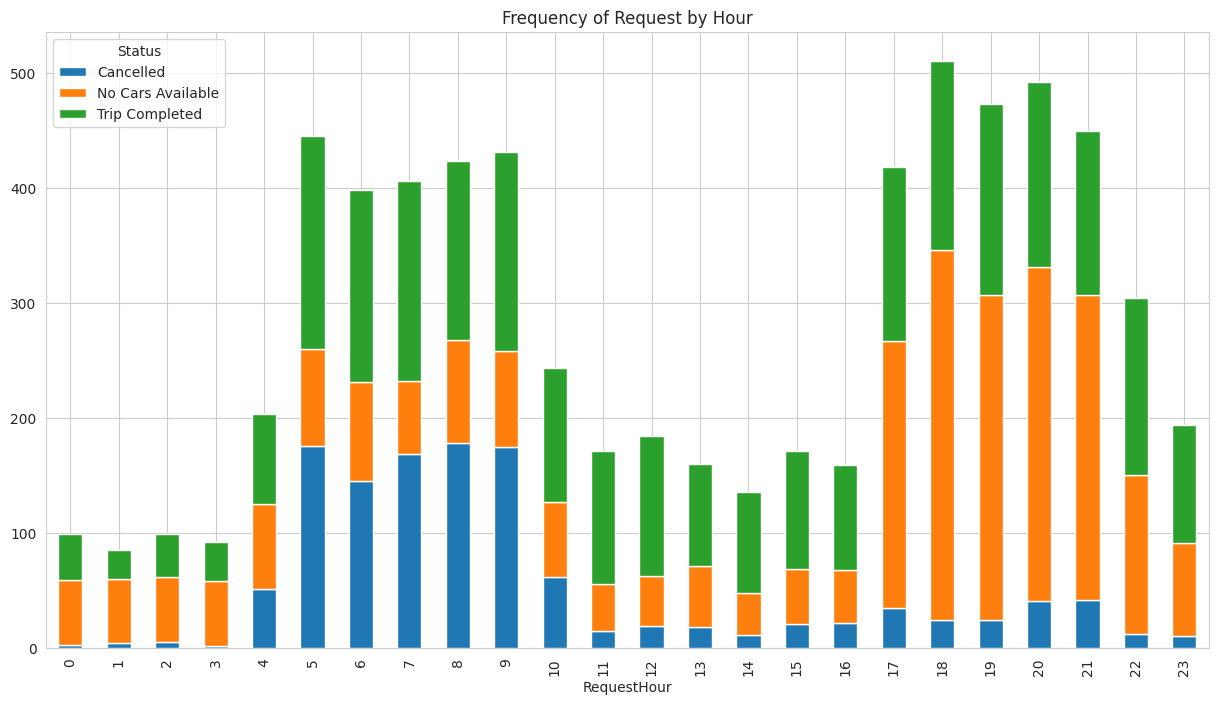

In [54]:
df.groupby(['RequestHour', 'Status']).size().unstack().plot(kind='bar', stacked=True, figsize=(15,8))

plt.title('Frequency of Request by Hour')

Type of requests (city-airport or airport-city)

Text(0, 0.5, '')

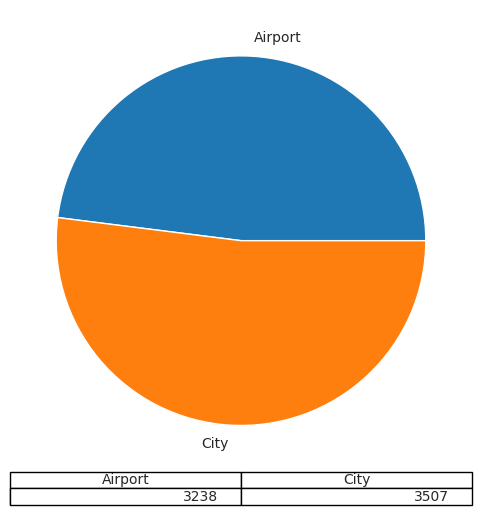

In [55]:
df.groupby(['Pickup point']).size().plot(kind='pie', stacked=True, figsize=(6,6), table=True)
plt.ylabel("")

Distribution of Time Slots

<Axes: >

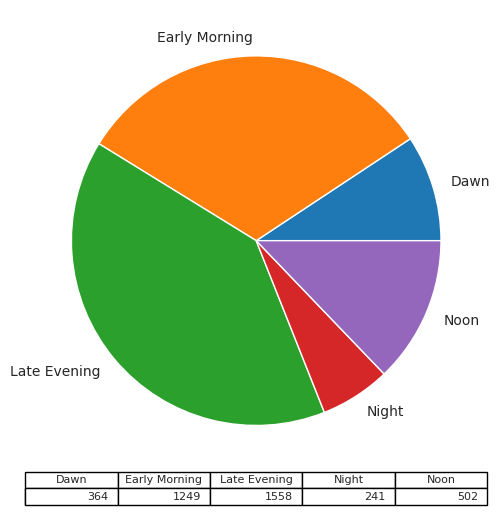

In [56]:
df[(df["Cab Availability"]=="Not Available")].groupby(['Timeslot']).size().plot(kind='pie', stacked=True, figsize=(6,6), table=True)

Demand-Supply Gap from Airport to City

Text(0.5, 1.0, 'Demand-Supply Gap from Airport to City')

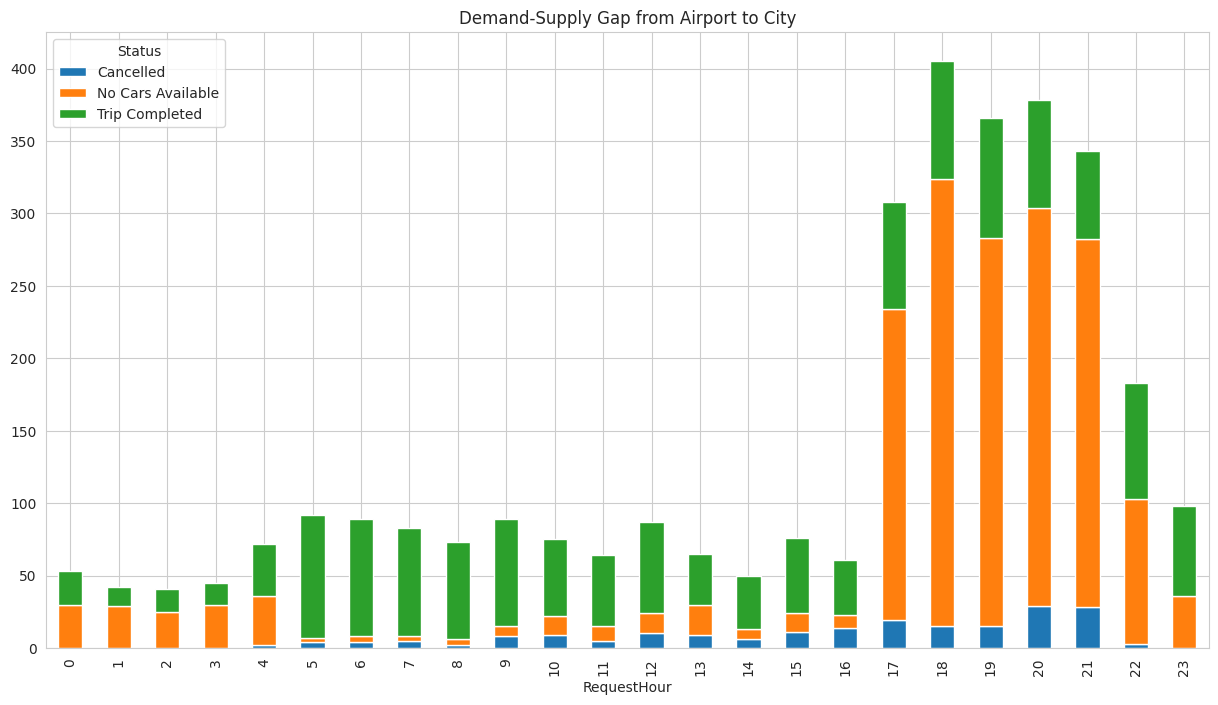

In [57]:
df[(df['Pickup point']=='Airport')].groupby(['RequestHour','Status']).size().unstack().plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Demand-Supply Gap from Airport to City')

Demand-Supply Gap from City to Airport

Text(0.5, 1.0, 'Demand-Supply Gap from City to Airport')

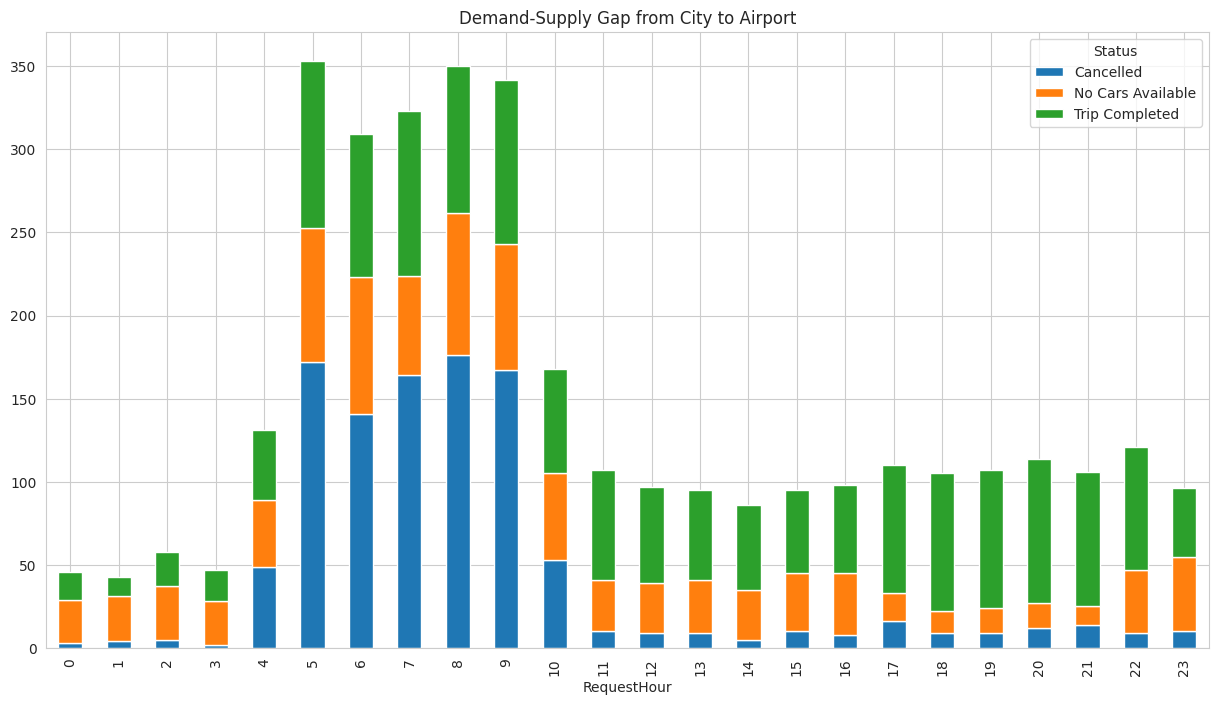

In [58]:
df[(df['Pickup point']=='City')].groupby(['RequestHour','Status']).size().unstack().plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Demand-Supply Gap from City to Airport')

What are the timeslots where the highest gap exists

Text(0.5, 1.0, 'Timeslot where the highest gap exists')

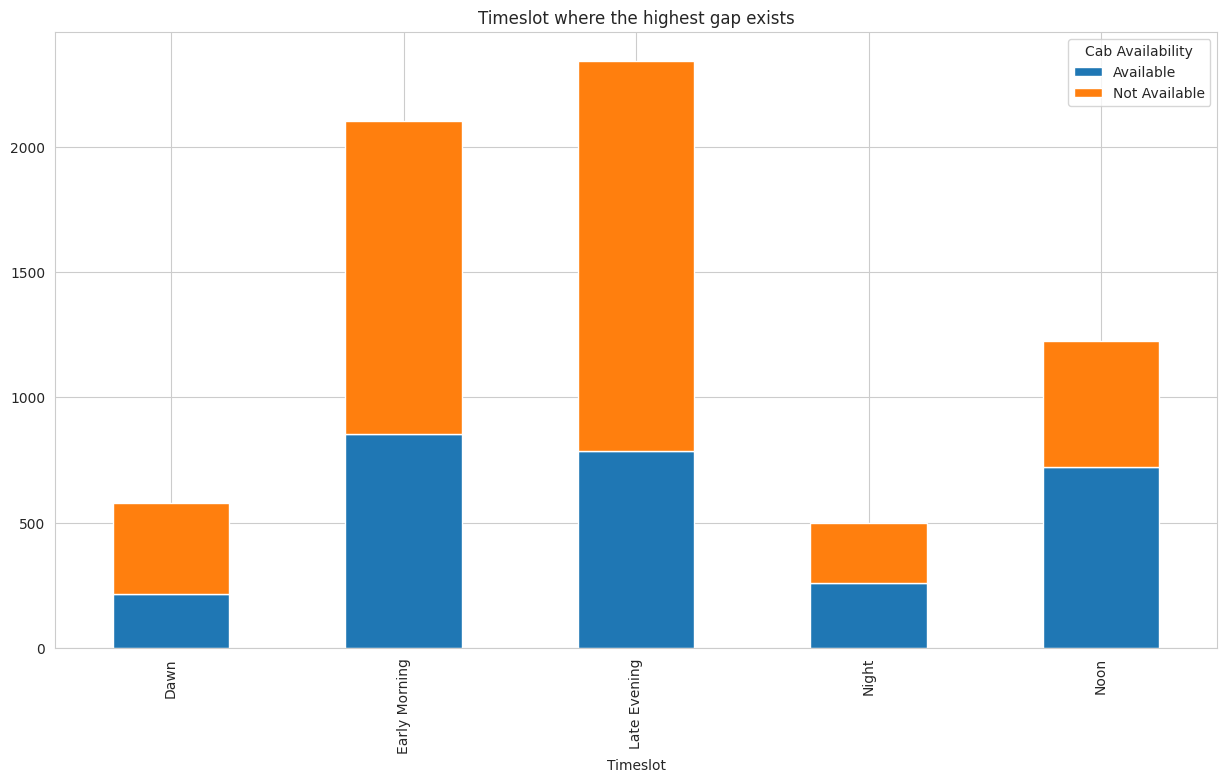

In [62]:
df.groupby(['Timeslot', 'Cab Availability']).size().unstack().plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Timeslot where the highest gap exists')

Types of Requests (city-airport or airport-city) for which the gap is the most severe in the identified time slots

Text(0, 0.5, '')

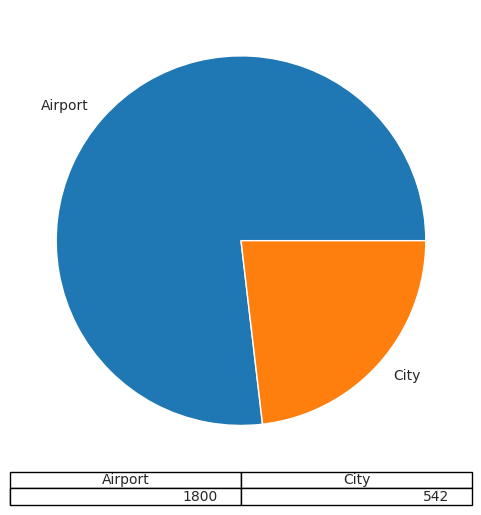

In [63]:
df[df['Timeslot']=='Late Evening'].groupby(['Pickup point']).size().plot(kind='pie', stacked=True, figsize=(6,6), table=True)
plt.ylabel("")

Text(0, 0.5, '')

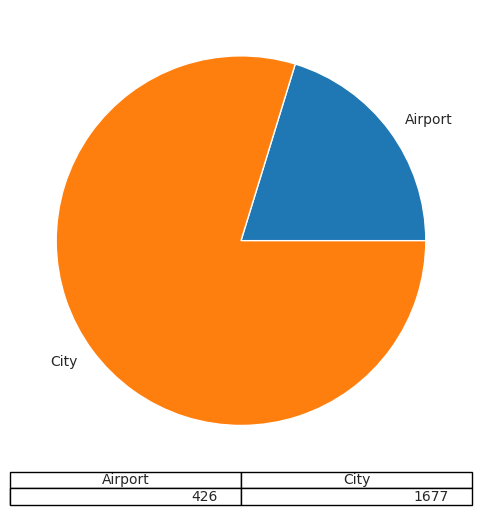

In [64]:
df[df['Timeslot']=='Early Morning'].groupby(['Pickup point']).size().plot(kind='pie', stacked=True, figsize=(6,6), table=True)
plt.ylabel("")

## Root Cause Analysis and Recommendations

### Reason for Supply-Demand Gap

1.  **Early Morning (5 AM - 9 AM):**
    *   There is a significant **cancellation problem for trips from the City to the Airport**. Drivers are likely cancelling these rides, possibly due to a reluctance to drive to the airport early in the morning and face a potentially empty return trip or less lucrative rides from the airport.

2.  **Late Evening/Night (5 PM - 10 PM):**
    *   There is a severe **'No Cars Available' issue for trips from the Airport to the City**. This indicates a shortage of drivers at the airport during these hours. Drivers might be dropping off passengers at the airport and then heading back to the city for more rides, or they might be unwilling to wait for a return fare from the airport, leading to a large demand-supply mismatch.

### Recommendations

1.  **To address Early Morning cancellations (City to Airport):**
    *   **Driver Incentives:** Offer incentives or bonuses for drivers accepting and completing City to Airport trips during early morning hours.
    *   **Dynamic Pricing:** Implement surge pricing for early morning City to Airport routes to attract more drivers.
    *   **Route Optimization:** Encourage drivers to take these trips by showcasing potential high-demand areas at the airport for immediate return trips.

2.  **To address Late Evening/Night 'No Cars Available' (Airport to City):**
    *   **Airport Driver Pool Incentives:** Provide incentives for drivers to remain at the airport or take rides from the airport to the city during late evening and night hours.
    *   **Queue Management:** Improve the system for drivers waiting at the airport, perhaps with a clear queuing system and estimated wait times to make it more predictable and appealing.
    *   **Predictive Dispatch:** Use predictive analytics to anticipate demand for airport pickups and guide drivers towards the airport during these peak unavailability times.